# MPVRP-CC : Multi-Product Vehicle Routing Problem with Changeover Cost

## TP - Optimisation de tournées de véhicules multi-produits

Ce notebook guide à travers la résolution du problème MPVRP-CC en utilisant Google OR-Tools.

### Objectifs du TP
1. Comprendre la structure du problème MPVRP-CC
2. Parser les fichiers d'instance
3. Implémenter et utiliser un solveur basé sur OR-Tools
4. Générer des solutions valides
5. Visualiser les résultats

## 1. Configuration de l'environnement

In [2]:
# Imports nécessaires
import sys
from pathlib import Path

# Ajouter le répertoire src au path
src_path = Path.cwd().parent / 'src' if (Path.cwd().parent / 'src').exists() else Path.cwd() / 'src'
sys.path.insert(0, str(src_path))

# Imports des modules du projet
from models import Instance, Solution, Vehicle, Depot, Garage, Station
from parser import parse_instance, validate_instance
from solver import solve_instance, MPVRPSolver
from solution_writer import write_solution, format_solution_for_display, validate_solution_locally
from visualizer import plot_instance, plot_solution

# Imports standards
import matplotlib.pyplot as plt
import numpy as np

print("✅ Tous les modules sont chargés avec succès!")

✅ Tous les modules sont chargés avec succès!


## 2. Exploration d'une instance

Commençons par charger et explorer une petite instance pour comprendre la structure du problème.

In [3]:
# Chemin vers les instances
base_path = Path.cwd().parent if (Path.cwd().parent / 'small').exists() else Path.cwd()
small_path = base_path / 'small'

# Lister les instances disponibles
instances = sorted(small_path.glob('*.dat'))
print(f"📁 {len(instances)} instances trouvées dans le dossier 'small'")
print("\nPremières instances:")
for inst in instances[:5]:
    print(f"  - {inst.name}")

📁 50 instances trouvées dans le dossier 'small'

Premières instances:
  - MPVRP_S_001_s9_d1_p2.dat
  - MPVRP_S_002_s10_d2_p3.dat
  - MPVRP_S_003_s12_d1_p2.dat
  - MPVRP_S_004_s9_d1_p3.dat
  - MPVRP_S_005_s7_d1_p3.dat


In [4]:
# Charger une instance
instance_file = small_path / 'MPVRP_S_012_s5_d2_p3.dat'
instance = parse_instance(instance_file)

print(instance)
print(f"\n📋 UUID: {instance.uuid}")

Instance MPVRP-CC:
  - 3 produits
  - 2 dépôts
  - 1 garages
  - 5 stations
  - 4 véhicules

📋 UUID: 2be526ee-c190-4d48-ae75-1ae339613c33


In [5]:
# Explorer les véhicules
print("🚛 Flotte de véhicules:")
print("-" * 60)
for v in instance.vehicles:
    print(f"  Véhicule {v.id}: Capacité={v.capacity}, Garage={v.home_garage}, Produit initial={v.initial_product}")

🚛 Flotte de véhicules:
------------------------------------------------------------
  Véhicule 1: Capacité=2850, Garage=1, Produit initial=2
  Véhicule 2: Capacité=4131, Garage=1, Produit initial=2
  Véhicule 3: Capacité=4444, Garage=1, Produit initial=1
  Véhicule 4: Capacité=1209, Garage=1, Produit initial=1


In [6]:
# Explorer les dépôts et leurs stocks
print("🏭 Dépôts et stocks:")
print("-" * 60)
for d in instance.depots:
    print(f"  Dépôt {d.id} à ({d.x:.1f}, {d.y:.1f})")
    for p, stock in enumerate(d.stocks):
        print(f"    └─ Produit {p+1}: {stock} unités")

🏭 Dépôts et stocks:
------------------------------------------------------------
  Dépôt 1 à (95.2, 54.9)
    └─ Produit 1: 5807 unités
    └─ Produit 2: 5875 unités
    └─ Produit 3: 7709 unités
  Dépôt 2 à (80.2, 5.3)
    └─ Produit 1: 6036 unités
    └─ Produit 2: 3687 unités
    └─ Produit 3: 9689 unités


In [7]:
# Explorer les demandes des stations
print("⛽ Stations et demandes:")
print("-" * 60)
for s in instance.stations:
    total = sum(s.demands)
    print(f"  Station {s.id} à ({s.x:.1f}, {s.y:.1f}) - Demande totale: {total}")
    for p, demand in enumerate(s.demands):
        if demand > 0:
            print(f"    └─ Produit {p+1}: {demand} unités")

⛽ Stations et demandes:
------------------------------------------------------------
  Station 1 à (41.9, 56.3) - Demande totale: 4833
    └─ Produit 2: 1105 unités
    └─ Produit 3: 3728 unités
  Station 2 à (66.1, 18.9) - Demande totale: 3009
    └─ Produit 1: 1156 unités
    └─ Produit 3: 1853 unités
  Station 3 à (71.7, 34.5) - Demande totale: 3616
    └─ Produit 1: 3616 unités
  Station 4 à (27.2, 55.5) - Demande totale: 7828
    └─ Produit 1: 4470 unités
    └─ Produit 3: 3358 unités
  Station 5 à (48.0, 65.1) - Demande totale: 3496
    └─ Produit 2: 2197 unités
    └─ Produit 3: 1299 unités


In [8]:
# Matrice de coûts de transition
print("🔄 Matrice de coûts de transition entre produits:")
print("-" * 60)
print("     ", end="")
for p in range(instance.nb_products):
    print(f"  P{p+1}   ", end="")
print()

for i, row in enumerate(instance.transition_costs):
    print(f"P{i+1}  ", end="")
    for cost in row:
        print(f"{cost:6.1f} ", end="")
    print()

🔄 Matrice de coûts de transition entre produits:
------------------------------------------------------------
       P1     P2     P3   
P1     0.0   26.9   17.0 
P2    39.7    0.0   13.5 
P3    45.3   13.7    0.0 


In [9]:
# Validation de l'instance
print("🔍 Validation de l'instance:")
is_valid = validate_instance(instance)
print(f"\n{'✅ Instance valide' if is_valid else '❌ Instance invalide'}")

# Vérifier l'équilibre offre/demande
print("\n📊 Équilibre offre/demande par produit:")
for p in range(instance.nb_products):
    demand = instance.get_total_demand(p)
    stock = instance.get_total_stock(p)
    status = "✅" if stock >= demand else "❌"
    print(f"  Produit {p+1}: Demande={demand}, Stock={stock} {status}")

🔍 Validation de l'instance:

✅ Instance valide

📊 Équilibre offre/demande par produit:
  Produit 1: Demande=9242, Stock=11843 ✅
  Produit 2: Demande=3302, Stock=9562 ✅
  Produit 3: Demande=10238, Stock=17398 ✅


## 3. Visualisation de l'instance

<Figure size 1000x800 with 0 Axes>

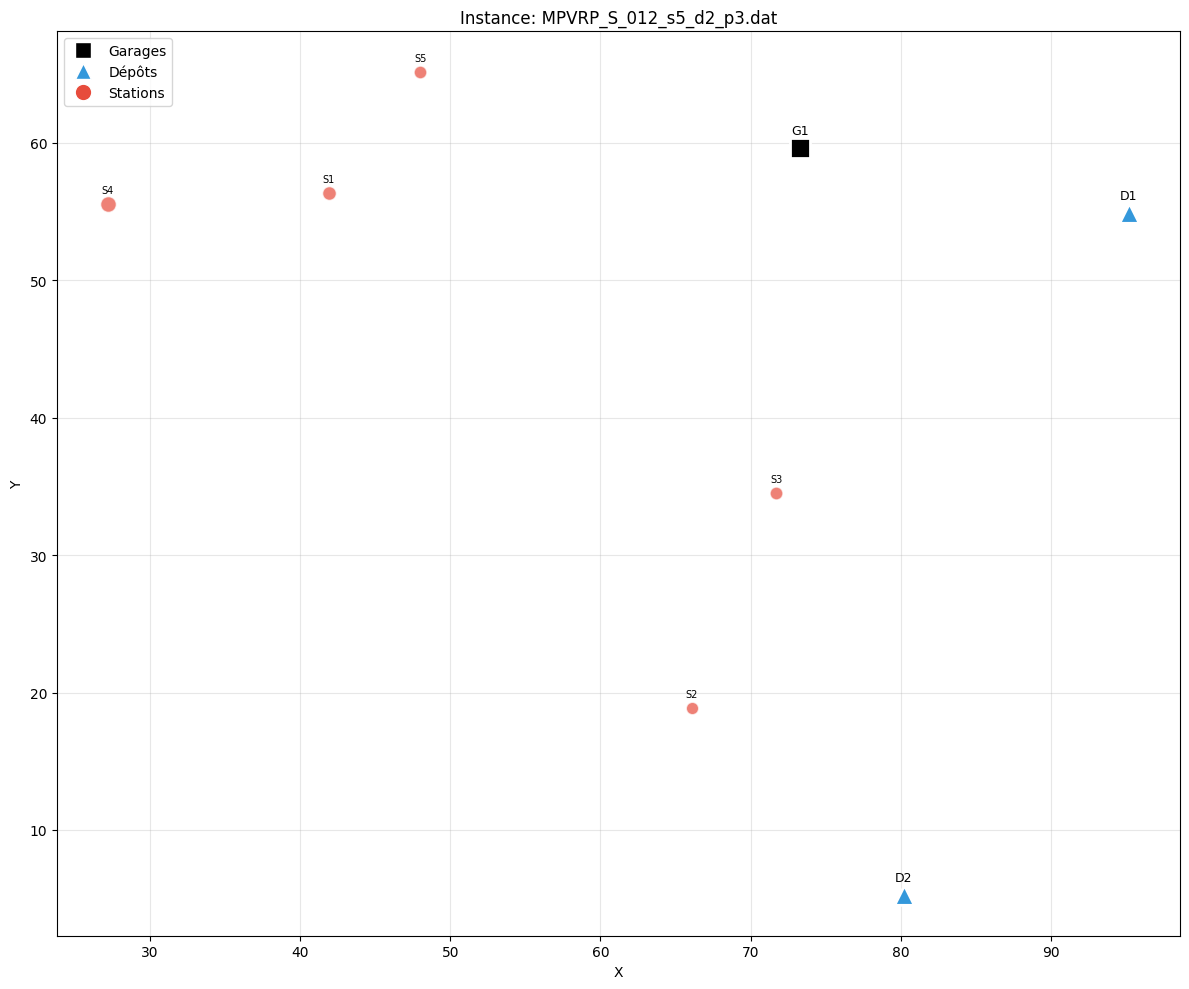

In [10]:
# Visualiser l'instance
plt.figure(figsize=(10, 8))
plot_instance(instance)
plt.title(f"Instance: {instance_file.name}")
plt.tight_layout()
plt.show()

## 4. Résolution avec OR-Tools

Utilisons maintenant le solveur pour trouver une solution.

In [11]:
# Résoudre l'instance
print("🔧 Résolution en cours...")
solution = solve_instance(instance, time_limit=30)

print("\n" + "="*60)
print(solution)
print("="*60)

🔧 Résolution en cours...

Solution MPVRP-CC:
  - Véhicules utilisés: 4
  - Distance totale: 1116.97
  - Coût de transition: 170.80
  - Coût total: 1287.77
  - Temps de résolution: 4.01s


In [12]:
# Afficher le détail de la solution
print(format_solution_for_display(solution))

SOLUTION MPVRP-CC

Véhicule 1 (Garage 1):
----------------------------------------
  Mini-route 1:
    Produit: 1
    Dépôt: 1 (chargé: 1156)
    Livraisons:
      - Station 2: 1156 unités
  Mini-route 2:
    Produit: 3
    Dépôt: 2 (chargé: 2850)
    Livraisons:
      - Station 4: 2850 unités
  Distance: 207.56
  Coût transition: 56.70

Véhicule 2 (Garage 1):
----------------------------------------
  Mini-route 1:
    Produit: 1
    Dépôt: 2 (chargé: 3261)
    Livraisons:
      - Station 4: 3261 unités
  Mini-route 2:
    Produit: 2
    Dépôt: 1 (chargé: 3302)
    Livraisons:
      - Station 5: 2197 unités
      - Station 1: 1105 unités
  Mini-route 3:
    Produit: 3
    Dépôt: 1 (chargé: 3152)
    Livraisons:
      - Station 2: 1853 unités
      - Station 5: 1299 unités
  Distance: 429.86
  Coût transition: 80.10

Véhicule 3 (Garage 1):
----------------------------------------
  Mini-route 1:
    Produit: 1
    Dépôt: 1 (chargé: 3616)
    Livraisons:
      - Station 3: 3616 unités
 

In [13]:
# Validation locale de la solution
is_valid, errors = validate_solution_locally(solution)
print(f"\n{'✅ Solution valide' if is_valid else '❌ Solution invalide'}")
if errors:
    print("Erreurs:")
    for e in errors:
        print(f"  - {e}")


✅ Solution valide


## 5. Visualisation de la solution

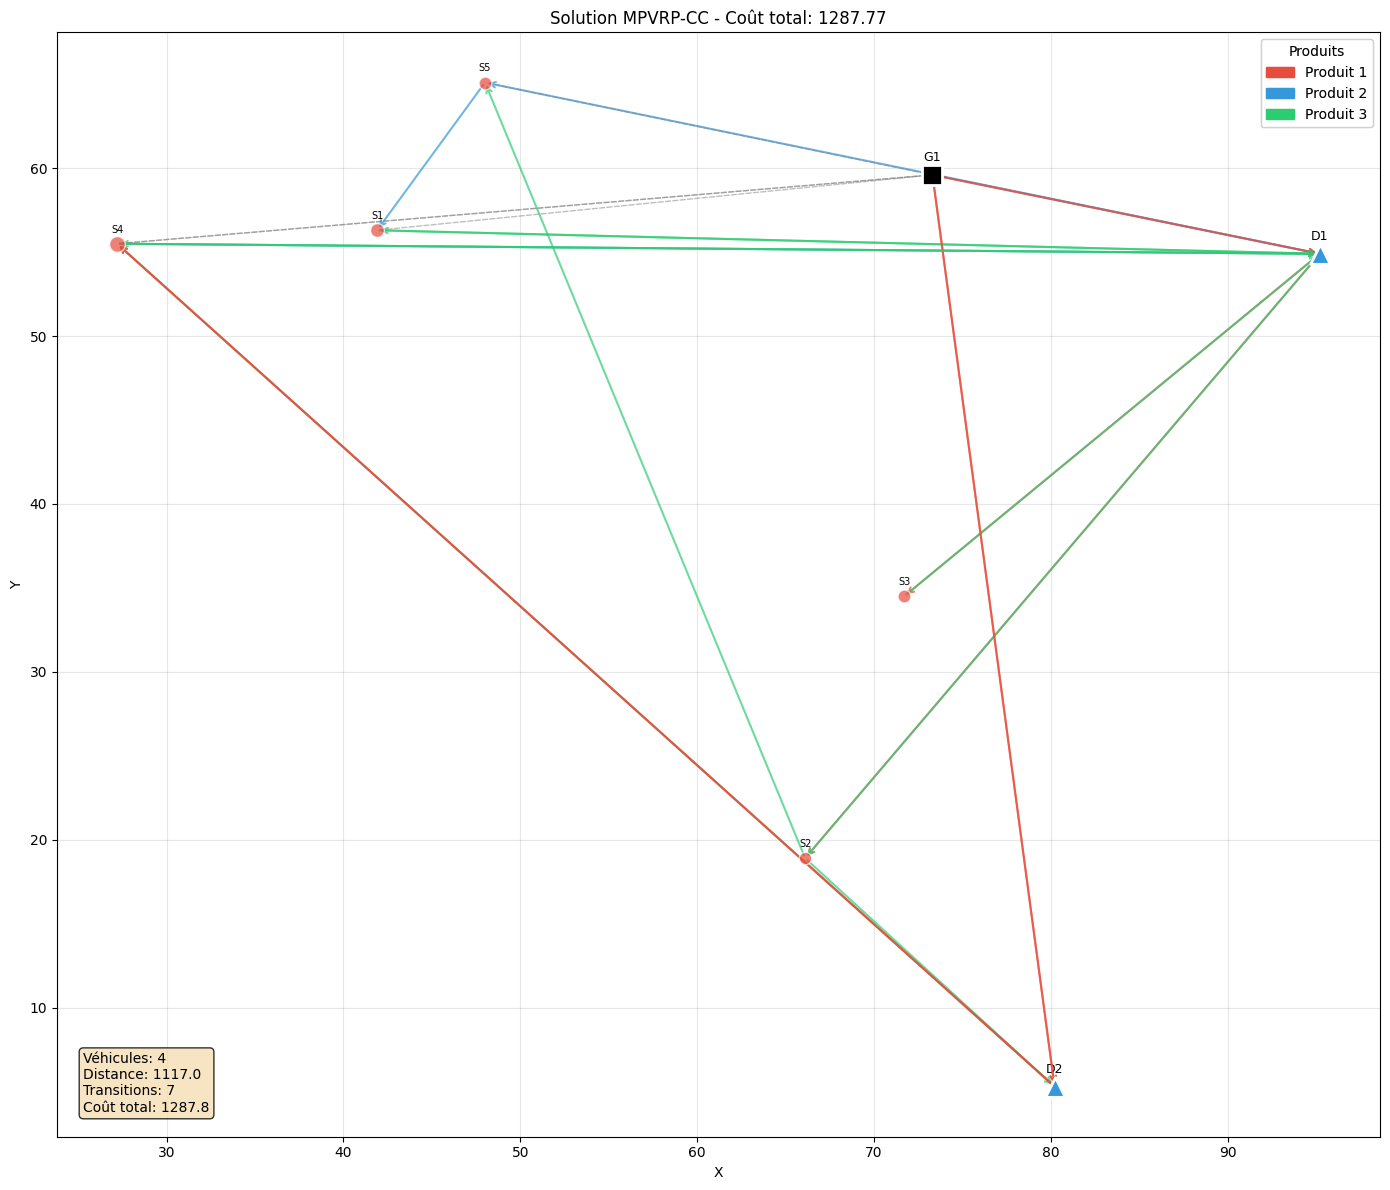

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: title={'center': 'Solution MPVRP-CC - Coût total: 1287.77'}, xlabel='X', ylabel='Y'>)

In [14]:
# Visualiser la solution
plot_solution(solution, show=True)

## 6. Sauvegarde de la solution

In [16]:
# Sauvegarder la solution
solution_path = base_path / 'solutions' / f"Sol_{instance_file.name}"
solution_path.parent.mkdir(parents=True, exist_ok=True)

write_solution(solution, solution_path)
print(f"💾 Solution sauvegardée: {solution_path}")

# Afficher le contenu du fichier
print("\n📄 Contenu du fichier de solution:")
print("-" * 60)
with open(solution_path, 'r') as f:
    print(f.read())

💾 Solution sauvegardée: c:\Users\CROSSHAIR\Desktop\Freelance\python\MPVRP-TP\solutions\Sol_MPVRP_S_012_s5_d2_p3.dat

📄 Contenu du fichier de solution:
------------------------------------------------------------
1: 1 - 1 [1156] - 2 (1156) - 2 [2850] - 4 (2850) - 1
1: 1(0.0) - 0(39.7) - 0(39.7) - 2(56.7) - 2(56.7) - 2(56.7)

2: 1 - 2 [3261] - 4 (3261) - 1 [3302] - 5 (2197) - 1 (1105) - 1 [3152] - 2 (1853) - 5 (1299) - 1
2: 1(0.0) - 0(39.7) - 0(39.7) - 1(66.6) - 1(66.6) - 1(66.6) - 2(80.1) - 2(80.1) - 2(80.1) - 2(80.1)

3: 1 - 1 [3616] - 3 (3616) - 1 [3728] - 1 (3728) - 1
3: 0(0.0) - 0(0.0) - 0(0.0) - 2(17.0) - 2(17.0) - 2(17.0)

4: 1 - 2 [1209] - 4 (1209) - 1 [508] - 4 (508) - 1
4: 0(0.0) - 0(0.0) - 0(0.0) - 2(17.0) - 2(17.0) - 2(17.0)

4
7
170.8
1117.0
Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
4.01


## 7. Résolution par lot (Batch)

Résolvons plusieurs instances pour comparer les performances.

In [17]:
# Résoudre les 5 premières instances small
results = []

for inst_file in instances[:5]:
    print(f"\n📍 Résolution de {inst_file.name}...", end=" ")
    
    try:
        inst = parse_instance(inst_file)
        sol = solve_instance(inst, time_limit=20)
        is_valid, _ = validate_solution_locally(sol)
        
        results.append({
            'instance': inst_file.name,
            'stations': inst.nb_stations,
            'products': inst.nb_products,
            'vehicles_used': sol.get_nb_vehicles_used(),
            'distance': sol.get_total_distance(),
            'transitions': sol.get_total_transitions(),
            'total_cost': sol.get_total_cost(),
            'time': sol.resolution_time,
            'valid': is_valid
        })
        print(f"{'✅' if is_valid else '❌'} Coût: {sol.get_total_cost():.1f} ({sol.resolution_time:.2f}s)")
    except Exception as e:
        print(f"❌ Erreur: {e}")

print("\n" + "="*80)
print("RÉCAPITULATIF")
print("="*80)


📍 Résolution de MPVRP_S_001_s9_d1_p2.dat... ✅ Coût: 978.9 (3.00s)

📍 Résolution de MPVRP_S_002_s10_d2_p3.dat... ✅ Coût: 2754.6 (4.01s)

📍 Résolution de MPVRP_S_003_s12_d1_p2.dat... ✅ Coût: 1469.3 (2.01s)

📍 Résolution de MPVRP_S_004_s9_d1_p3.dat... ✅ Coût: 2182.3 (3.00s)

📍 Résolution de MPVRP_S_005_s7_d1_p3.dat... ✅ Coût: 795.8 (2.00s)

RÉCAPITULATIF


In [18]:
# Afficher les résultats sous forme de tableau
import pandas as pd

if results:
    df = pd.DataFrame(results)
    print(df.to_string(index=False))
    
    print(f"\n📊 Statistiques:")
    print(f"  - Solutions valides: {df['valid'].sum()}/{len(df)}")
    print(f"  - Coût moyen: {df['total_cost'].mean():.1f}")
    print(f"  - Temps moyen: {df['time'].mean():.2f}s")

                 instance  stations  products  vehicles_used    distance  transitions  total_cost     time  valid
 MPVRP_S_001_s9_d1_p2.dat         9         2              3  888.140925            5  978.940925 3.004356   True
MPVRP_S_002_s10_d2_p3.dat        10         3              5 2359.509043           12 2754.609043 4.005372   True
MPVRP_S_003_s12_d1_p2.dat        12         2              2 1413.671924            2 1469.271924 2.006582   True
 MPVRP_S_004_s9_d1_p3.dat         9         3              5 1966.084266            7 2182.284266 3.003969   True
 MPVRP_S_005_s7_d1_p3.dat         7         3              2  597.119955            5  795.819955 2.003176   True

📊 Statistiques:
  - Solutions valides: 5/5
  - Coût moyen: 1636.2
  - Temps moyen: 2.80s


## 8. Analyse des performances

Analysons la composition du coût total.

📊 Décomposition du coût de la solution:
----------------------------------------
Distance totale: 1116.97
Coût de transition: 170.80
Coût total: 1287.77

Répartition: Distance 86.7% | Transition 13.3%


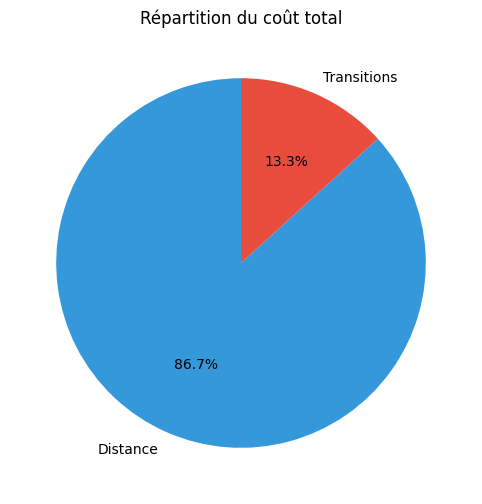

In [19]:
# Analyse de la dernière solution
print("📊 Décomposition du coût de la solution:")
print("-" * 40)
print(f"Distance totale: {solution.get_total_distance():.2f}")
print(f"Coût de transition: {solution.get_total_transition_cost():.2f}")
print(f"Coût total: {solution.get_total_cost():.2f}")

# Ratio
dist_ratio = solution.get_total_distance() / solution.get_total_cost() * 100
trans_ratio = solution.get_total_transition_cost() / solution.get_total_cost() * 100
print(f"\nRépartition: Distance {dist_ratio:.1f}% | Transition {trans_ratio:.1f}%")

# Graphique
fig, ax = plt.subplots(figsize=(8, 6))
costs = [solution.get_total_distance(), solution.get_total_transition_cost()]
labels = ['Distance', 'Transitions']
colors = ['#3498db', '#e74c3c']

ax.pie(costs, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Répartition du coût total')
plt.show()

## 9. Conclusion

Ce TP a présenté:
1. **Le problème MPVRP-CC** : un VRP multi-produits avec coûts de changement
2. **Le parsing** des fichiers d'instance au format .dat
3. **La résolution** avec OR-Tools (décomposition par produit)
4. **La validation** locale des solutions
5. **La visualisation** des instances et solutions

### Points d'amélioration possibles:
- Optimisation de l'ordre des produits à traiter
- Prise en compte des coûts de transition dans la fonction objectif
- Heuristiques de post-optimisation
- Parallélisation pour les grandes instances